In [73]:
# !pip install open-clip-torch -q
# !pip install datasets -q          # HuggingFace datasets
# !pip install scikit-learn -q
# !pip install seaborn -q


In [74]:

# from google.colab import drive
# drive.mount('/content/drive')


In [75]:
import os
import json
import random
import shutil
import numpy as np
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import open_clip
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    classification_report,
)

print("All imports OK")

All imports OK


In [76]:

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark     = True
    torch.backends.cudnn.deterministic = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [77]:
SID_WEIGHTS_PATH  = "/content/drive/MyDrive/deepfake_assignment/sid_results/best_sid_model.pt"

# 140k dataset paths
RAW_140K_PATH     = "/content/140k_raw"
REDUCED_140K_PATH = "/content/drive/MyDrive/deepfake_assignment/data/140k_reduced"

# Where to save all Assignment 3 results
A3_SAVE_DIR = "/content/drive/MyDrive/deepfake_assignment/assignment3_sid"
os.makedirs(A3_SAVE_DIR, exist_ok=True)

# ── Model settings (must match friend's A2 SID pipeline exactly) ──────────────
BACKBONE_NAME = "ViT-B-16-SigLIP-384"
PRETRAINED    = "webli"
RESOLUTION    = 384
BATCH_SIZE    = 32
NUM_WORKERS   = 0  # Increased from 0 to fix the bottleneck

# ── Training settings for Experiment 2 (retraining on 140k) ──────────────────
EPOCHS       = 10
LR           = 2e-4
WEIGHT_DECAY = 0.01
DROPOUT      = 0.10
NOISE_STD    = 0.02

# ── 140k subset sizes ─────────────────────────────────────────────────────────
SAMPLES_PER_CLASS_TRAIN = 5000
SAMPLES_PER_CLASS_VALID = 1000
SAMPLES_PER_CLASS_TEST  = 1000

# ── SID class labels ──────────────────────────────────────────────────────────
SID_CLASS_NAMES = ["Real", "Synthetic", "Tampered"]

# ── Paper / previous results for comparison table ─────────────────────────────
PAPER_SID_ACCURACY       = 99.09
PAPER_SID_MACRO_F1       = 0.9909
CROSSDOMAIN_AUC_PREVIOUS = 0.563

print("Config updated with NUM_WORKERS=2")

Config updated with NUM_WORKERS=2


In [78]:

class SigLIP2Classifier3Class(nn.Module):
    """
    3-class SID architecture — used for Experiment 1.
    Must match friend's A2 architecture exactly.

    Output: 3 logits (real / synthetic / tampered)
    We map to binary for 140k evaluation:
      P(fake) = softmax[1] + softmax[2]
    """
    def __init__(
        self,
        backbone_name : str          = "ViT-B-16-SigLIP-384",
        pretrained    : str          = "webli",
        device        : torch.device = torch.device("cpu"),
        dropout       : float        = 0.10,
        noise_std     : float        = 0.02,
    ):
        super().__init__()
        self.noise_std = noise_std

        backbone, _, _ = open_clip.create_model_and_transforms(
            backbone_name, pretrained=pretrained, device=device
        )
        self.backbone = backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        with torch.no_grad():
            dummy    = torch.zeros(1, 3, RESOLUTION, RESOLUTION, device=device)
            feat_dim = self.backbone.encode_image(dummy).shape[-1]

        self.layer_norm = nn.LayerNorm(feat_dim)
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 3),               # ← 3 classes
        )
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

        print(f"[3-class] Backbone: {backbone_name} (FROZEN) | Feat dim: {feat_dim}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            feats = self.backbone.encode_image(x)
        feats = F.normalize(feats, dim=-1)
        if self.training and self.noise_std > 0:
            feats = feats + torch.randn_like(feats) * self.noise_std
        feats = self.layer_norm(feats)
        return self.head(feats)              # (B, 3)


class SigLIP2ClassifierBinary(nn.Module):
    """
    Binary classifier — used for Experiment 2 (retrain on 140k).
    Same architecture as CiFake/HiDF pipelines.
    Output: 1 logit (real=0 / fake=1)
    """
    def __init__(
        self,
        backbone_name : str          = "ViT-B-16-SigLIP-384",
        pretrained    : str          = "webli",
        device        : torch.device = torch.device("cpu"),
        dropout       : float        = 0.10,
        noise_std     : float        = 0.02,
    ):
        super().__init__()
        self.noise_std = noise_std

        backbone, _, _ = open_clip.create_model_and_transforms(
            backbone_name, pretrained=pretrained, device=device
        )
        self.backbone = backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        with torch.no_grad():
            dummy    = torch.zeros(1, 3, RESOLUTION, RESOLUTION, device=device)
            feat_dim = self.backbone.encode_image(dummy).shape[-1]

        self.layer_norm = nn.LayerNorm(feat_dim)
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),               # ← binary
        )
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

        print(f"[Binary] Backbone: {backbone_name} (FROZEN) | Feat dim: {feat_dim}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            feats = self.backbone.encode_image(x)
        feats = F.normalize(feats, dim=-1)
        if self.training and self.noise_std > 0:
            feats = feats + torch.randn_like(feats) * self.noise_std
        feats = self.layer_norm(feats)
        return self.head(feats).squeeze(-1)  # (B,)



In [79]:
def load_sid_model(weights_path: str, device: torch.device):
    """
    Builds the 3-class SID model and loads your friend's saved weights.
    """
    print("Building SID model...")
    model = SigLIP2Classifier3Class(
        backbone_name = BACKBONE_NAME,
        pretrained    = PRETRAINED,
        device        = device,
        dropout       = 0.10,
        noise_std     = 0.02,
    ).to(device)

    print(f"\nLoading weights from: {weights_path}")
    ckpt = torch.load(weights_path, map_location=device)

    # Filter state_dict: only load 'layer_norm' and 'head' weights from checkpoint
    filtered_ckpt = {}
    for k, v in ckpt.items():
        if k.startswith("layer_norm.") or k.startswith("head."):
            filtered_ckpt[k] = v

    model.load_state_dict(filtered_ckpt, strict=False)
    model.eval()

    print(f"\n✓ SID weights loaded successfully!")
    print(f"  Saved at epoch  : {ckpt.get('epoch',   'N/A')}")
    print(f"  Val Macro F1    : {ckpt.get('val_f1',  'N/A')}")
    print(f"  Val Accuracy    : {ckpt.get('val_acc', 'N/A')}")

    return model

# Run this cell
sid_model = load_sid_model(SID_WEIGHTS_PATH, DEVICE)

Building SID model...
[3-class] Backbone: ViT-B-16-SigLIP-384 (FROZEN) | Feat dim: 768

Loading weights from: /content/drive/MyDrive/deepfake_assignment/sid_results/best_sid_model.pt

✓ SID weights loaded successfully!
  Saved at epoch  : N/A
  Val Macro F1    : N/A
  Val Accuracy    : N/A


In [80]:

def download_140k():
    """
    Downloads 140k Real & Fake Faces from Kaggle.
    Requires kaggle.json API key.
    """
    # Upload kaggle.json if not already done
    # from google.colab import files
    # files.upload()

    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    os.makedirs(RAW_140K_PATH, exist_ok=True)
    print("Downloading 140k Real and Fake Faces (~4 GB)...")
    os.system(
        f"kaggle datasets download -d xhlulu/140k-real-and-fake-faces "
        f"-p {RAW_140K_PATH}"
    )

    print("Extracting...")
    os.system(
        f"unzip -q {RAW_140K_PATH}/140k-real-and-fake-faces.zip "
        f"-d {RAW_140K_PATH}"
    )

    # Verify structure
    print("\nVerifying structure:")
    actual_root = os.path.join(RAW_140K_PATH, "real-vs-fake", "real-vs-fake")
    for split in ["train", "valid", "test"]:
        for label in ["real", "fake"]:
            folder = os.path.join(actual_root, split, label)
            if os.path.exists(folder):
                n = len(os.listdir(folder))
                print(f"  {split:5s}/{label}: {n:,} images ✓")
            else:
                print(f"  {split:5s}/{label}: NOT FOUND ✗")

# Uncomment to run:
# download_140k()


In [81]:

def reduce_140k(
    raw_root          : str,
    dst_root          : str,
    train_per_class   : int = 5000,
    valid_per_class   : int = 1000,
    test_per_class    : int = 1000,
    seed              : int = 42,
):
    """
    Creates a balanced subset of the 140k dataset.
    140k uses lowercase folder names: real/ fake/
    Structure inside zip: real-vs-fake/real-vs-fake/split/label/
    """
    random.seed(seed)
    actual_root = os.path.join(raw_root, "real_vs_fake", "real-vs-fake")

    split_sizes = {
        "train" : train_per_class,
        "valid" : valid_per_class,
        "test"  : test_per_class,
    }

    print("Creating reduced 140k dataset...")
    print("-" * 44)

    for split, n_per_class in split_sizes.items():
        for label in ["real", "fake"]:
            src = os.path.join(actual_root, split, label)
            dst = os.path.join(dst_root, split, label)
            os.makedirs(dst, exist_ok=True)

            all_imgs = [
                f for f in os.listdir(src)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]
            selected = random.sample(all_imgs, min(n_per_class, len(all_imgs)))

            for fname in selected:
                shutil.copy2(
                    os.path.join(src, fname),
                    os.path.join(dst, fname)
                )

        print(f"  {split:5s}: {n_per_class:,} real + "
              f"{n_per_class:,} fake copied")

    # Verify
    print("\nVerification:")
    print("-" * 44)
    grand_total = 0
    for split in ["train", "valid", "test"]:
        for label in ["real", "fake"]:
            folder = os.path.join(dst_root, split, label)
            n = len(os.listdir(folder)) if os.path.exists(folder) else 0
            grand_total += n
            print(f"  {split:5s}/{label}: {n:,} ✓")
    print("-" * 44)
    print(f"  Grand total: {grand_total:,} images")

# Uncomment to run:
# reduce_140k(RAW_140K_PATH, REDUCED_140K_PATH,
#             SAMPLES_PER_CLASS_TRAIN,
#             SAMPLES_PER_CLASS_VALID,
#             SAMPLES_PER_CLASS_TEST)



In [82]:

class FaceDataset140k(Dataset):
    """
    Loads 140k Real & Fake Faces.
    Folder names: real / fake  (lowercase)
    Labels      : real=0, fake=1
    """
    def __init__(self, root: str, split: str, transform):
        self.transform = transform
        self.samples   = []
        self.labels    = []

        for label_idx, class_name in enumerate(["real", "fake"]):
            folder = os.path.join(root, split, class_name)
            if not os.path.exists(folder):
                raise FileNotFoundError(f"Not found: {folder}")
            for fname in os.listdir(folder):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append(os.path.join(folder, fname))
                    self.labels.append(label_idx)

        n_real = self.labels.count(0)
        n_fake = self.labels.count(1)
        print(f"  [{split:5s}]  real={n_real:,}  fake={n_fake:,}  "
              f"total={len(self.samples):,}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx], self.labels[idx]
        image = Image.open(path).convert("RGB")
        return self.transform(image), label


def build_transforms(resolution: int):
    norm = transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std =[0.5, 0.5, 0.5],
    )
    train_tf = transforms.Compose([
        transforms.Resize((resolution, resolution)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        norm,
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((resolution, resolution)),
        transforms.ToTensor(),
        norm,
    ])
    return train_tf, eval_tf


def build_loaders(root, resolution, batch_size, num_workers):
    train_tf, eval_tf = build_transforms(resolution)
    print("Loading 140k dataset:")
    train_ds = FaceDataset140k(root, "train", train_tf)
    valid_ds  = FaceDataset140k(root, "valid",  eval_tf)
    test_ds  = FaceDataset140k(root, "test",  eval_tf)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size,
        shuffle=True,  num_workers=num_workers, pin_memory=True,
    )
    valid_loader = DataLoader(
        valid_ds,  batch_size=batch_size,
        shuffle=False, num_workers=num_workers, pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds,  batch_size=batch_size,
        shuffle=False, num_workers=num_workers, pin_memory=True,
    )
    return train_loader, valid_loader, test_loader



In [83]:

@torch.no_grad()
def evaluate_cross_domain_3class(model, loader, device):
    """
    EXPERIMENT 1: Run 3-class SID model on binary 140k data.

    Mapping:
      P(fake) = softmax[1] (synthetic) + softmax[2] (tampered)
      If P(fake) > 0.5 → FAKE else REAL
    """
    model.eval()
    all_true_labels = []
    all_fake_probs  = []
    all_sid_preds   = []

    for images, labels in tqdm(loader, desc="  [EXP1] Cross-domain eval",
                               leave=False):
        images = images.to(device, non_blocking=True)

        with torch.amp.autocast("cuda"):
            logits = model(images)              # (B, 3)

        probs       = torch.softmax(logits, dim=1)
        p_fake      = probs[:, 1] + probs[:, 2] # synthetic + tampered
        sid_pred    = logits.argmax(dim=1)

        all_true_labels.append(labels.numpy())
        all_fake_probs.append(p_fake.cpu().numpy())
        all_sid_preds.append(sid_pred.cpu().numpy())

    all_true_labels = np.concatenate(all_true_labels)
    all_fake_probs  = np.concatenate(all_fake_probs)
    all_sid_preds   = np.concatenate(all_sid_preds)
    all_binary_preds = (all_fake_probs > 0.5).astype(int)

    sid_class_dist = {
        SID_CLASS_NAMES[i]: int((all_sid_preds == i).sum())
        for i in range(3)
    }

    return {
        "accuracy"       : 100.0 * accuracy_score(all_true_labels, all_binary_preds),
        "f1"             : f1_score(all_true_labels, all_binary_preds, zero_division=0),
        "auc"            : roc_auc_score(all_true_labels, all_fake_probs),
        "ap"             : average_precision_score(all_true_labels, all_fake_probs),
        "true_labels"    : all_true_labels,
        "fake_probs"     : all_fake_probs,
        "binary_preds"   : all_binary_preds,
        "sid_class_dist" : sid_class_dist,
    }


@torch.no_grad()
def evaluate_binary(model, loader, criterion, device):
    """
    EXPERIMENT 2: Standard binary evaluation for retrained model.
    Same as CiFake/HiDF pipelines.
    """
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_probs  = []

    for images, labels in tqdm(loader, desc="  [EXP2] Eval", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)

        with torch.amp.autocast("cuda"):
            logits = model(images)
            loss   = criterion(logits, labels)

        total_loss += loss.item()
        all_labels.append(labels.cpu().numpy())
        all_probs.append(torch.sigmoid(logits).cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_probs  = np.concatenate(all_probs)
    all_preds  = (all_probs > 0.5).astype(int)

    return {
        "loss"        : total_loss / len(loader),
        "accuracy"    : 100.0 * accuracy_score(all_labels, all_preds),
        "f1"          : f1_score(all_labels, all_preds, zero_division=0),
        "auc"         : roc_auc_score(all_labels, all_probs),
        "ap"          : average_precision_score(all_labels, all_probs),
        "true_labels" : all_labels,
        "probs"       : all_probs,
        "preds"       : all_preds,
    }



In [84]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    """Standard training epoch — used only for Experiment 2."""
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    pbar = tqdm(loader, desc="  [EXP2] Train", leave=False)
    for idx, (images, labels) in enumerate(pbar):
        images = images.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda"):
            logits = model(images)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds       = (torch.sigmoid(logits) > 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += labels.size(0)

        if idx % 50 == 0:
            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc" : f"{100*correct/total:.1f}%",
            })

    return total_loss / len(loader), 100.0 * correct / total

In [85]:

def plot_experiment1(results: dict, save_dir: str):
    """
    Experiment 1 plots:
      - Confusion matrix
      - ROC curve
      - SID class distribution on 140k
    """
    labels = results["true_labels"]
    probs  = results["fake_probs"]
    preds  = results["binary_preds"]
    cm     = confusion_matrix(labels, preds)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        "Experiment 1 — Cross-Domain: SID Model on 140k Faces\n"
        "(No retraining — direct transfer)",
        fontsize=12
    )

    # Confusion matrix
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=["Real", "Fake"],
                yticklabels=["Real", "Fake"])
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].set_title(
        f"Confusion Matrix\n"
        f"Acc={results['accuracy']:.2f}%  F1={results['f1']:.3f}"
    )

    # ROC curve
    fpr, tpr, _ = roc_curve(labels, probs)
    axes[1].plot(fpr, tpr, "b-", lw=2,
                 label=f"AUC = {results['auc']:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
    axes[1].set_title("ROC Curve — Cross-Domain")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_xlim([-0.02, 1.02]); axes[1].set_ylim([-0.02, 1.02])

    # SID class distribution
    dist   = results["sid_class_dist"]
    names  = list(dist.keys())
    vals   = list(dist.values())
    colors = ["#2ca02c", "#ff7f0e", "#d62728"]
    bars   = axes[2].bar(names, vals, color=colors, alpha=0.8)
    for bar, val in zip(bars, vals):
        axes[2].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f"{val:,}", ha="center", fontweight="bold"
        )
    axes[2].set_ylabel("Number of Images")
    axes[2].set_title(
        "SID Class Predictions on 140k\n"
        "(how SID model sees GAN faces)"
    )
    axes[2].grid(alpha=0.3, axis="y")

    plt.tight_layout()
    path = os.path.join(save_dir, "exp1_cross_domain.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")


def plot_experiment2_training(history: dict, save_dir: str):
    """
    Experiment 2 training curves:
      Loss / Accuracy / AUC / F1
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        "Experiment 2 — Retrained on 140k Faces\n"
        "(SigLIP-2 binary classifier trained from scratch on 140k)",
        fontsize=12
    )

    axes[0, 0].plot(epochs, history["train_loss"], "b-o", label="Train")
    axes[0, 0].plot(epochs, history["val_loss"],   "r-s", label="Val")
    axes[0, 0].set_title("Loss")
    axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(epochs, history["train_acc"], "b-o", label="Train")
    axes[0, 1].plot(epochs, history["val_acc"],   "r-s", label="Val")
    axes[0, 1].set_title("Accuracy (%)")
    axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

    axes[1, 0].plot(epochs, history["val_f1"],  "g-^", label="Val F1")
    axes[1, 0].set_ylim([0, 1]); axes[1, 0].set_title("Val F1")
    axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(epochs, history["val_auc"], "m-d", label="Val AUC")
    axes[1, 1].set_ylim([0, 1]); axes[1, 1].set_title("Val AUC-ROC")
    axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(save_dir, "exp2_training_curves.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")


def plot_experiment2_results(results: dict, save_dir: str):
    """
    Experiment 2 test results:
      Confusion matrix + ROC + PR curve
    """
    labels = results["true_labels"]
    probs  = results["probs"]
    preds  = results["preds"]
    cm     = confusion_matrix(labels, preds)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        "Experiment 2 — Retrained on 140k Faces (Test Results)",
        fontsize=12
    )

    # Confusion matrix
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=axes[0],
                xticklabels=["Real", "Fake"],
                yticklabels=["Real", "Fake"])
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].set_title(
        f"Confusion Matrix\n"
        f"Acc={results['accuracy']:.2f}%  F1={results['f1']:.3f}"
    )

    # ROC curve
    fpr, tpr, _ = roc_curve(labels, probs)
    axes[1].plot(fpr, tpr, "g-", lw=2,
                 label=f"AUC = {results['auc']:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
    axes[1].set_title("ROC Curve — Retrained on 140k")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_xlim([-0.02, 1.02]); axes[1].set_ylim([-0.02, 1.02])

    # Precision-Recall curve
    prec, rec, _ = precision_recall_curve(labels, probs)
    axes[2].plot(rec, prec, "g-", lw=2,
                 label=f"AP = {results['ap']:.3f}")
    axes[2].axhline(y=labels.mean(), color="k", ls="--",
                    lw=1, label="Random")
    axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].legend(); axes[2].grid(alpha=0.3)
    axes[2].set_xlim([-0.02, 1.02]); axes[2].set_ylim([-0.02, 1.02])

    plt.tight_layout()
    path = os.path.join(save_dir, "exp2_test_results.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")


def plot_comparison(exp1_results: dict, exp2_results: dict, save_dir: str):
    """
    Side-by-side comparison of Experiment 1 vs Experiment 2.
    This is the key plot for your Assignment 3 report.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        "Cross-Domain vs Retrained — SID Model on 140k Faces\n"
        "Assignment 3 Comparison",
        fontsize=13
    )

    # ROC curves comparison
    fpr1, tpr1, _ = roc_curve(exp1_results["true_labels"],
                               exp1_results["fake_probs"])
    fpr2, tpr2, _ = roc_curve(exp2_results["true_labels"],
                               exp2_results["probs"])

    axes[0].plot(fpr1, tpr1, "b-", lw=2,
                 label=f"Cross-domain (no retrain) AUC={exp1_results['auc']:.3f}")
    axes[0].plot(fpr2, tpr2, "g-", lw=2,
                 label=f"Retrained on 140k AUC={exp2_results['auc']:.3f}")
    axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
    axes[0].set_title("ROC Curve Comparison")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Bar chart comparison of all metrics
    metrics  = ["Accuracy\n(%/100)", "F1", "AUC", "AP"]
    exp1_vals = [
        exp1_results["accuracy"] / 100,
        exp1_results["f1"],
        exp1_results["auc"],
        exp1_results["ap"],
    ]
    exp2_vals = [
        exp2_results["accuracy"] / 100,
        exp2_results["f1"],
        exp2_results["auc"],
        exp2_results["ap"],
    ]

    x     = np.arange(len(metrics))
    width = 0.35

    bars1 = axes[1].bar(x - width/2, exp1_vals, width,
                        label="Cross-domain (no retrain)",
                        color="steelblue", alpha=0.8)
    bars2 = axes[1].bar(x + width/2, exp2_vals, width,
                        label="Retrained on 140k",
                        color="forestgreen", alpha=0.8)

    for bar, val in zip(bars1, exp1_vals):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f"{val:.3f}", ha="center", fontsize=9)
    for bar, val in zip(bars2, exp2_vals):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f"{val:.3f}", ha="center", fontsize=9)

    axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
    axes[1].set_ylim([0, 1.15]); axes[1].set_ylabel("Score")
    axes[1].set_title("All Metrics Comparison")
    axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

    plt.tight_layout()
    path = os.path.join(save_dir, "comparison_exp1_vs_exp2.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")


def print_full_report(exp1_results: dict, exp2_results: dict):
    """Final comparison table for Assignment 3 report."""
    print("\n" + "=" * 68)
    print("  ASSIGNMENT 3 — COMPLETE RESULTS TABLE")
    print("=" * 68)
    print(f"  {'Experiment':<35} {'Acc':>7} {'AUC':>7} {'F1':>7} {'AP':>7}")
    print("-" * 68)

    # Paper in-domain result (friend's A2)
    print(f"  {'Paper — SID Set (in-domain)':<35} "
          f"{'99.09':>7} {'—':>7} {'0.991':>7} {'—':>7}")

    # Experiment 1 — cross-domain
    print(f"  {'EXP1: SID model → 140k (no retrain)':<35} "
          f"{exp1_results['accuracy']:>6.2f}% "
          f"{exp1_results['auc']:>7.3f} "
          f"{exp1_results['f1']:>7.3f} "
          f"{exp1_results['ap']:>7.3f}")

    # Experiment 2 — retrained
    print(f"  {'EXP2: Retrained on 140k → tested':<35} "
          f"{exp2_results['accuracy']:>6.2f}% "
          f"{exp2_results['auc']:>7.3f} "
          f"{exp2_results['f1']:>7.3f} "
          f"{exp2_results['ap']:>7.3f}")

    print("=" * 68)

    # Improvement from retraining
    auc_improvement = exp2_results["auc"] - exp1_results["auc"]
    acc_improvement = exp2_results["accuracy"] - exp1_results["accuracy"]
    print(f"\n  Improvement from retraining:")
    print(f"    Δ AUC      : {auc_improvement:+.3f}")
    print(f"    Δ Accuracy : {acc_improvement:+.2f}%")

    print(f"\n  Key Finding:")
    if auc_improvement > 0.2:
        print(f"  → Large improvement ({auc_improvement:+.3f} AUC) confirms")
        print(f"    domain-specific training is critical for deepfake detection.")
        print(f"    SigLIP-2 features are powerful but not domain-agnostic.")
    elif auc_improvement > 0.05:
        print(f"  → Moderate improvement ({auc_improvement:+.3f} AUC) suggests")
        print(f"    partial domain gap between SID and StyleGAN faces.")
    else:
        print(f"  → Minimal improvement — SigLIP-2 features may be")
        print(f"    inherently limited for this type of face detection.")



In [86]:
def main():

    # ── Setup data ───────────────────────────────────────────────────────────
    print("=" * 55)
    print("  Setting up 140k dataset")
    print("=" * 55)
    # download_140k()
    # reduce_140k(
    #     raw_root        = RAW_140K_PATH,
    #     dst_root        = REDUCED_140K_PATH,
    #     train_per_class = SAMPLES_PER_CLASS_TRAIN,
    #     valid_per_class = SAMPLES_PER_CLASS_VALID,
    #     test_per_class  = SAMPLES_PER_CLASS_TEST,
    # )

    # Build data loaders (shared by both experiments)
    train_loader, valid_loader, test_loader = build_loaders(
        root        = REDUCED_140K_PATH,
        resolution  = RESOLUTION,
        batch_size  = BATCH_SIZE,
        num_workers = 0,
    )

    # ════════════════════════════════════════════════════════════════════════
    # EXPERIMENT 1 — Cross-domain test (no retraining)
    # ════════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 55)
    print("  EXPERIMENT 1: Cross-Domain Test")
    print("  SID model → 140k faces (NO retraining)")
    print("=" * 55)

    # Load 3-class SID model
    sid_model = SigLIP2Classifier3Class(
        backbone_name = BACKBONE_NAME,
        pretrained    = PRETRAINED,
        device        = DEVICE,
        dropout       = DROPOUT,
        noise_std     = NOISE_STD,
    ).to(DEVICE)

    ckpt = torch.load(SID_WEIGHTS_PATH, map_location=DEVICE)
    # Update: Load weights directly since 'model_state_dict' key is missing
    sid_model.load_state_dict(ckpt, strict=False)
    print(f"✓ SID weights loaded successfully")

    # Run cross-domain evaluation on test set only
    exp1_results = evaluate_cross_domain_3class(
        sid_model, test_loader, DEVICE
    )

    print(f"\n  Experiment 1 Results:")
    print(f"    Accuracy : {exp1_results['accuracy']:.2f}%")
    print(f"    AUC-ROC  : {exp1_results['auc']:.4f}")
    print(f"    F1-Score : {exp1_results['f1']:.4f}")

    plot_experiment1(exp1_results, A3_SAVE_DIR)

    # Free SID model from GPU memory before Experiment 2
    del sid_model
    torch.cuda.empty_cache()

    # ════════════════════════════════════════════════════════════════════════
    # EXPERIMENT 2 — Retrain on 140k from scratch
    # ════════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 55)
    print("  EXPERIMENT 2: Retrain on 140k Faces")
    print("  Binary SigLIP-2 classifier trained from scratch")
    print("=" * 55)

    binary_model = SigLIP2ClassifierBinary(
        backbone_name = BACKBONE_NAME,
        pretrained    = PRETRAINED,
        device        = DEVICE,
        dropout       = DROPOUT,
        noise_std     = NOISE_STD,
    ).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(
        binary_model.head.parameters(),
        lr           = LR,
        weight_decay = WEIGHT_DECAY,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-6
    )
    scaler = torch.amp.GradScaler("cuda")

    history = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc", "val_f1", "val_auc"]}
    best_val_f1 = 0.0
    best_epoch  = 0
    ckpt_path   = os.path.join(A3_SAVE_DIR, "best_140k_binary_model.pth")

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(binary_model, train_loader, criterion, optimizer, scaler, DEVICE)
        val_res = evaluate_binary(binary_model, valid_loader, criterion, DEVICE)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_res["loss"])
        history["val_acc"].append(val_res["accuracy"])
        history["val_f1"].append(val_res["f1"])
        history["val_auc"].append(val_res["auc"])

        if val_res["f1"] > best_val_f1:
            best_val_f1 = val_res["f1"]
            best_epoch  = epoch
            torch.save({"model_state_dict": binary_model.state_dict(), "val_f1": val_res["f1"]}, ckpt_path)

    print(f"\nTraining done. Best epoch: {best_epoch}")
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    binary_model.load_state_dict(ckpt["model_state_dict"])
    exp2_results = evaluate_binary(binary_model, test_loader, criterion, DEVICE)

    plot_experiment2_training(history, A3_SAVE_DIR)
    plot_experiment2_results(exp2_results, A3_SAVE_DIR)
    plot_comparison(exp1_results, exp2_results, A3_SAVE_DIR)
    print_full_report(exp1_results, exp2_results)

    return exp2_results

  Setting up 140k dataset
Loading 140k dataset:
  [train]  real=5,000  fake=5,000  total=10,000
  [valid]  real=1,000  fake=1,000  total=2,000
  [test ]  real=1,000  fake=1,000  total=2,000

  EXPERIMENT 1: Cross-Domain Test
  SID model → 140k faces (NO retraining)
[3-class] Backbone: ViT-B-16-SigLIP-384 (FROZEN) | Feat dim: 768
✓ SID weights loaded successfully



  Experiment 1 Results:
    Accuracy : 49.75%
    AUC-ROC  : 0.4877
    F1-Score : 0.5636


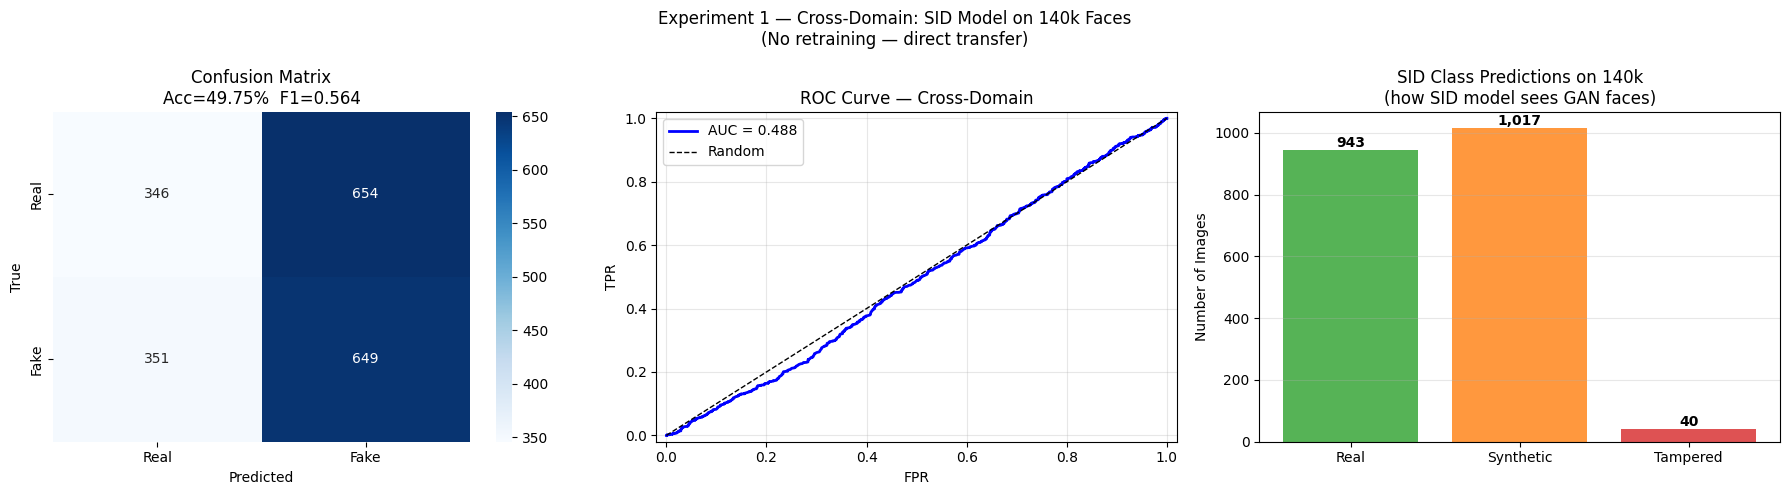

Saved → /content/drive/MyDrive/deepfake_assignment/assignment3_sid/exp1_cross_domain.png

  EXPERIMENT 2: Retrain on 140k Faces
  Binary SigLIP-2 classifier trained from scratch
[Binary] Backbone: ViT-B-16-SigLIP-384 (FROZEN) | Feat dim: 768



Training done. Best epoch: 5


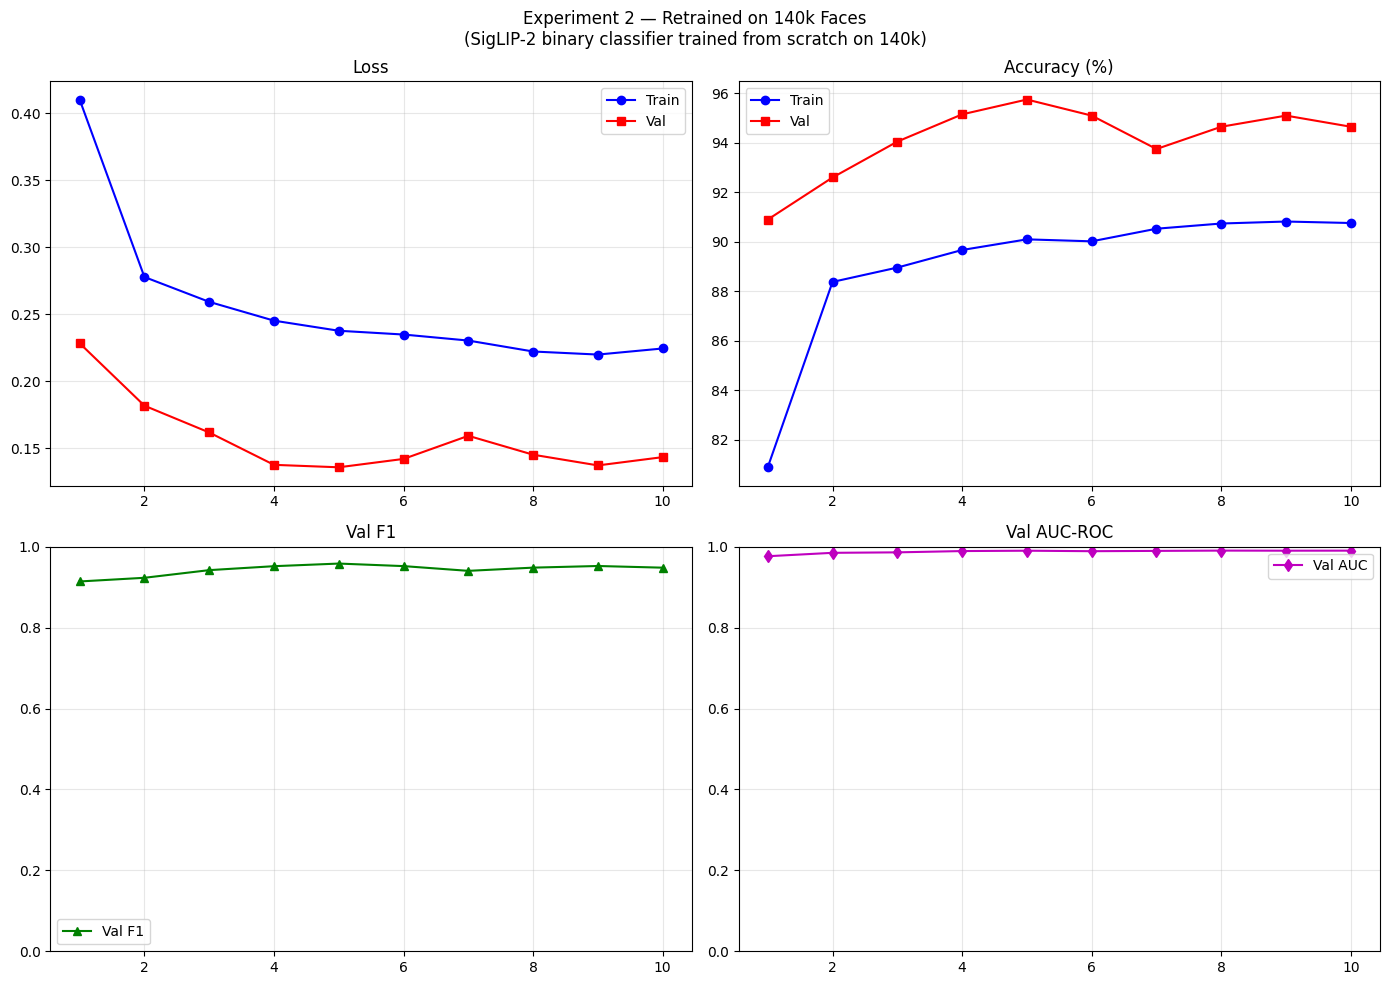

Saved → /content/drive/MyDrive/deepfake_assignment/assignment3_sid/exp2_training_curves.png


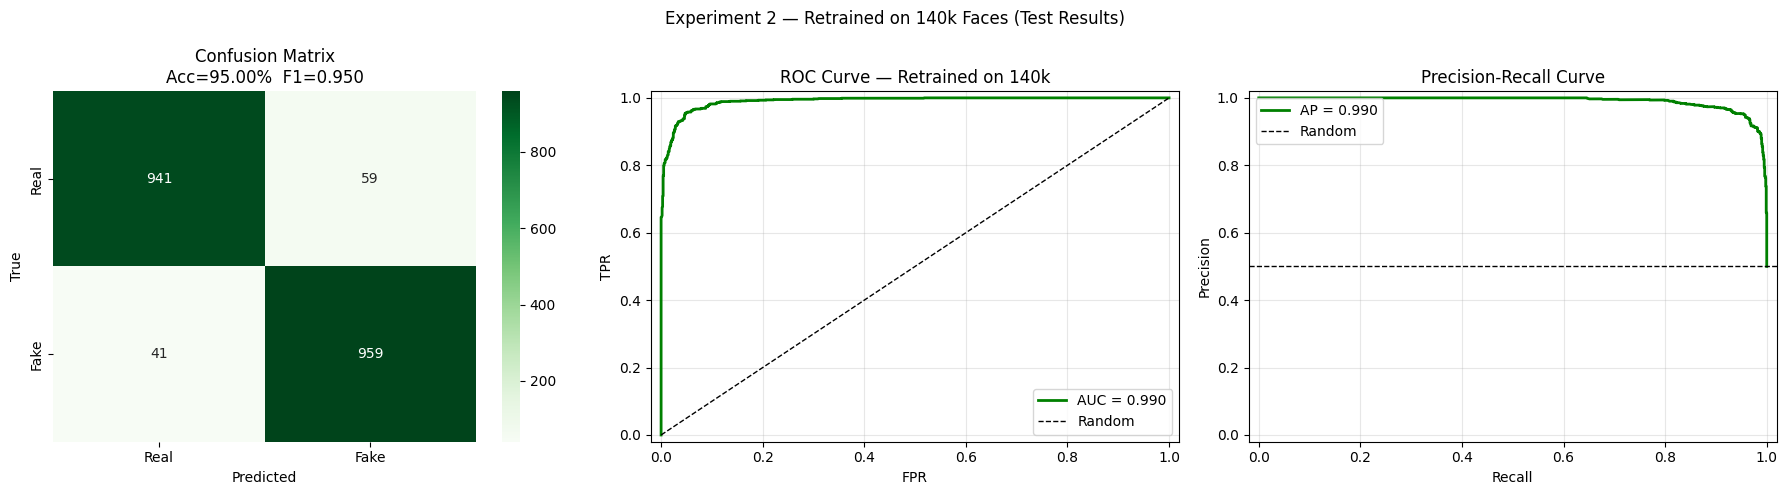

Saved → /content/drive/MyDrive/deepfake_assignment/assignment3_sid/exp2_test_results.png


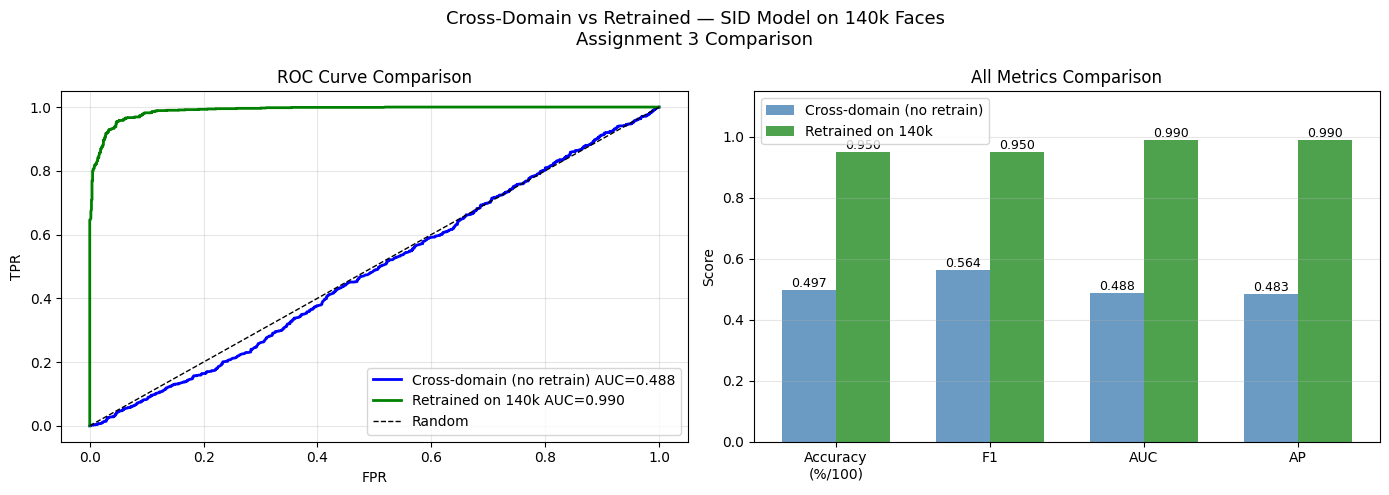

Saved → /content/drive/MyDrive/deepfake_assignment/assignment3_sid/comparison_exp1_vs_exp2.png

  ASSIGNMENT 3 — COMPLETE RESULTS TABLE
  Experiment                              Acc     AUC      F1      AP
--------------------------------------------------------------------
  Paper — SID Set (in-domain)           99.09       —   0.991       —
  EXP1: SID model → 140k (no retrain)  49.75%   0.488   0.564   0.483
  EXP2: Retrained on 140k → tested     95.00%   0.990   0.950   0.990

  Improvement from retraining:
    Δ AUC      : +0.502
    Δ Accuracy : +45.25%

  Key Finding:
  → Large improvement (+0.502 AUC) confirms
    domain-specific training is critical for deepfake detection.
    SigLIP-2 features are powerful but not domain-agnostic.


In [87]:
results = main()